Running trajectory generation on device: cpu

Differentiable physics simulation complete: 3000 states tracked.


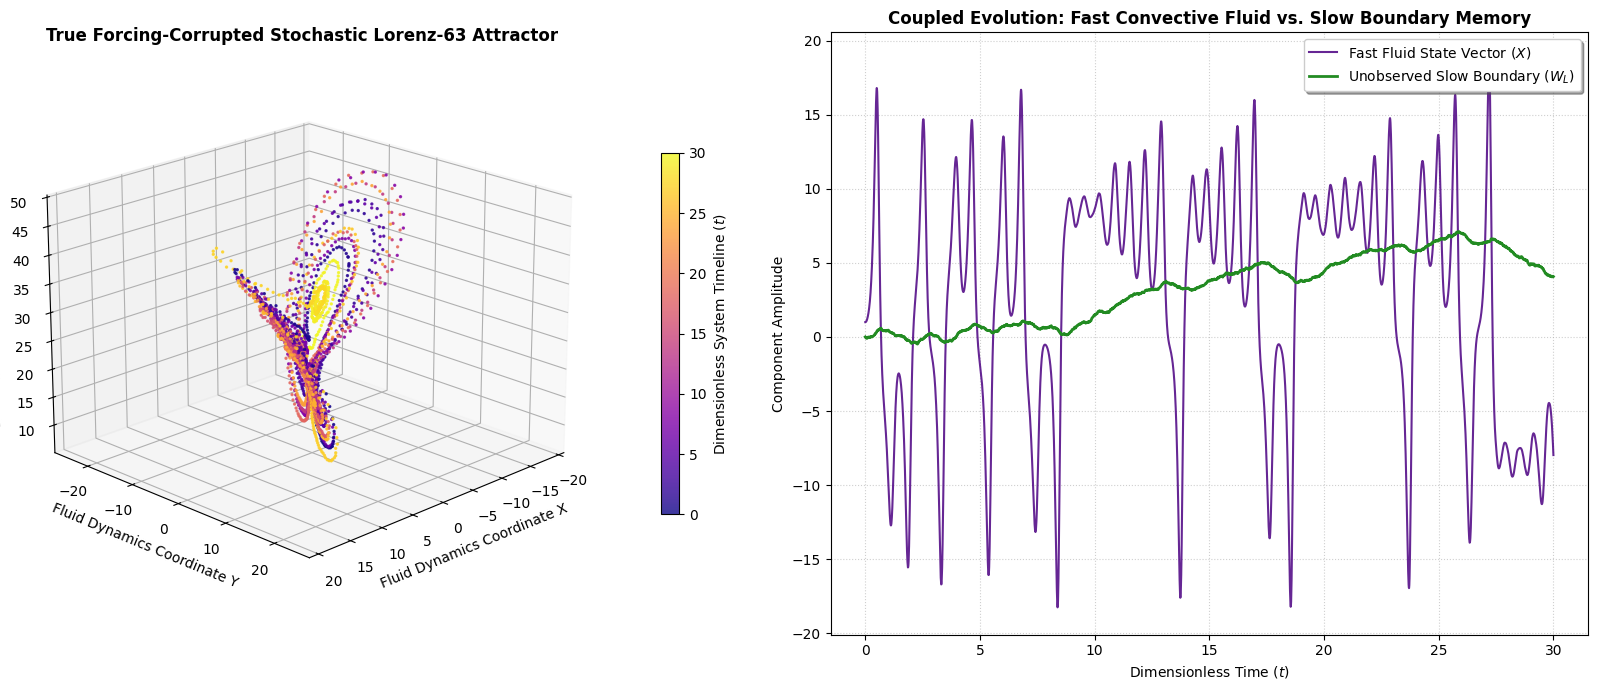

In [1]:
# ==============================================================================
# CELL 1: DIFFERENTIABLE PHYSICAL TRAJECTORY GENERATION & ATTRACTOR VISUALIZATION
# ==============================================================================
# This cell uses fully differentiable PyTorch operators to solve the 4D continuous-
# time Stochastic Lorenz-63 system under unobserved boundary forcing and state-
# dependent (multiplicative) subgrid volatility (Chapron-inspired physics).
# ==============================================================================

import torch
import numpy as np
import matplotlib.pyplot as plt

# Ensure reproducible torch tensor states
torch.manual_seed(42)
np.random.seed(42)

# Select GPU acceleration if available inside Colab
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Running trajectory generation on device: {device}\n")

# ------------------------------------------------------------------------------
# 1. PHYSICAL CONSTANTS & CALIBRATION SETUP
# ------------------------------------------------------------------------------
sigma = torch.tensor(10.0, device=device)
rho   = torch.tensor(28.0, device=device)
beta  = torch.tensor(8/3,  device=device)

gamma     = torch.tensor(0.05, device=device)  # Slow boundary relaxation rate
W_L_bar   = torch.tensor(0.0,  device=device)  # Land equilibrium baseline
c1        = torch.tensor(1.0,  device=device)  # Land-to-Fluid coupling strength
c2        = torch.tensor(0.1,  device=device)  # Fluid-to-Land coupling strength

sigma_0   = torch.tensor(0.08, device=device)  # Chapron state-dependent coefficient
sigma_L   = torch.tensor(0.20, device=device)  # Independent continuous land noise

# Time Integration Constraints
dt = 0.01
T_max = 30.0
num_steps = int(T_max / dt)
time_grid = np.linspace(0, T_max, num_steps)

# ------------------------------------------------------------------------------
# 2. DIFFERENTIABLE SDE SOLVER (Euler-Maruyama Implementation)
# ------------------------------------------------------------------------------
def generate_stochastic_l63_trajectory(initial_state, steps, dt):
    """
    Simulates the true coupled physical system using differentiable PyTorch steps.
    State vector layout: [X, Y, Z, W_L]
    """
    # Pre-allocate tensor trajectory array to preserve computation graph tracking
    trajectory = torch.zeros((steps, 4), device=device, dtype=torch.float32)
    trajectory[0] = initial_state

    # Pre-generate standard Normal random variations for fast parallelized computation
    # dW = Z * sqrt(dt) -> standard Wiener process increments
    noise_increments = torch.randn((steps, 3), device=device, dtype=torch.float32) * np.sqrt(dt)

    for t in range(1, steps):
        # Extract previous time step states while preserving differentiability
        X, Y, Z, W_L = trajectory[t-1, 0], trajectory[t-1, 1], trajectory[t-1, 2], trajectory[t-1, 3]

        # Pull independent pre-generated random noise scalars
        dW1, dW2, dW3 = noise_increments[t, 0], noise_increments[t, 1], noise_increments[t, 2]

        # Compute Deterministic Drift Vectors (Model Physics)
        dX   = sigma * (Y - X) + c1 * W_L
        dY   = X * (rho - Z) - Y
        dZ   = X * Y - beta * Z
        dW_L = -gamma * (W_L - W_L_bar) + c2 * X

        # Continuous integration step combining drift + state-dependent diffusion paths
        X_next   = X + dX * dt
        Y_next   = Y + dY * dt + (sigma_0 * Y * dW1)  # Multiplicative flaring noise
        Z_next   = Z + dZ * dt + (sigma_0 * Z * dW2)  # Multiplicative flaring noise
        W_L_next = W_L + dW_L * dt + (sigma_L * dW3)  # Additive land noise

        # Pack states sequentially into the differentiable output array
        trajectory[t] = torch.stack([X_next, Y_next, Z_next, W_L_next])

    return trajectory

# Define initial condition directly on the chaotic attractor manifold
# Enabling requires_grad=True allows calculation of initial condition sensitivity
init_state = torch.tensor([1.0, 1.0, 20.0, 0.0], device=device, requires_grad=True)

# Generate True Trajectory Space
true_trajectory_tensor = generate_stochastic_l63_trajectory(init_state, num_steps, dt)

# Move tracking variables to CPU for clean matplotlib processing
true_trajectory = true_trajectory_tensor.detach().cpu().numpy()
fluid_components = true_trajectory[:, :3]
land_component   = true_trajectory[:, 3]

print(f"Differentiable physics simulation complete: {true_trajectory.shape[0]} states tracked.")

# ------------------------------------------------------------------------------
# 3. HIGH-FIDELITY ATTRACTOR VISUALIZATION
# ------------------------------------------------------------------------------
fig = plt.figure(figsize=(16, 7))

# Plot A: 3D Mapping of the Chaotic Stochastic Attractor
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
# Set up line segments styled by color gradient to illustrate timeline evolution
scatter = ax1.scatter(fluid_components[:, 0], fluid_components[:, 1], fluid_components[:, 2],
                      c=time_grid, cmap='plasma', s=2, alpha=0.8)
ax1.set_title("True Forcing-Corrupted Stochastic Lorenz-63 Attractor", fontsize=12, fontweight='bold')
ax1.set_xlabel("Fluid Dynamics Coordinate X", fontsize=10)
ax1.set_ylabel("Fluid Dynamics Coordinate Y", fontsize=10)
ax1.set_zlabel("Fluid Dynamics Coordinate Z", fontsize=10)
cbar = fig.colorbar(scatter, ax=ax1, pad=0.1, shrink=0.6)
cbar.set_label('Dimensionless System Timeline ($t$)', fontsize=10)
ax1.view_init(elev=20, azim=45)

# Plot B: Coupled Time Series Detailing Flaring Volatility and Slow Boundary Memory
ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(time_grid, fluid_components[:, 0], label='Fast Fluid State Vector ($X$)', color='indigo', alpha=0.85)
ax2.plot(time_grid, land_component, label='Unobserved Slow Boundary ($W_L$)', color='forestgreen', linewidth=2)
ax2.set_title("Coupled Evolution: Fast Convective Fluid vs. Slow Boundary Memory", fontsize=12, fontweight='bold')
ax2.set_xlabel("Dimensionless Time ($t$)", fontsize=10)
ax2.set_ylabel("Component Amplitude", fontsize=10)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(loc='upper right', frameon=True, shadow=True)

plt.tight_layout()
plt.show()

Data generation running on: cpu



/tmp/ipykernel_12045/3836279811.py:97: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  d_eta = -(1.0 / tau_eta) * eta[t-1] * dt + sigma_eta * np.sqrt(2.0 / tau_eta) * np.random.normal(0, np.sqrt(dt))


Data Generation complete for window size T = 5 units.
Total system steps cached : 500
Number of sparse observations generated : 24



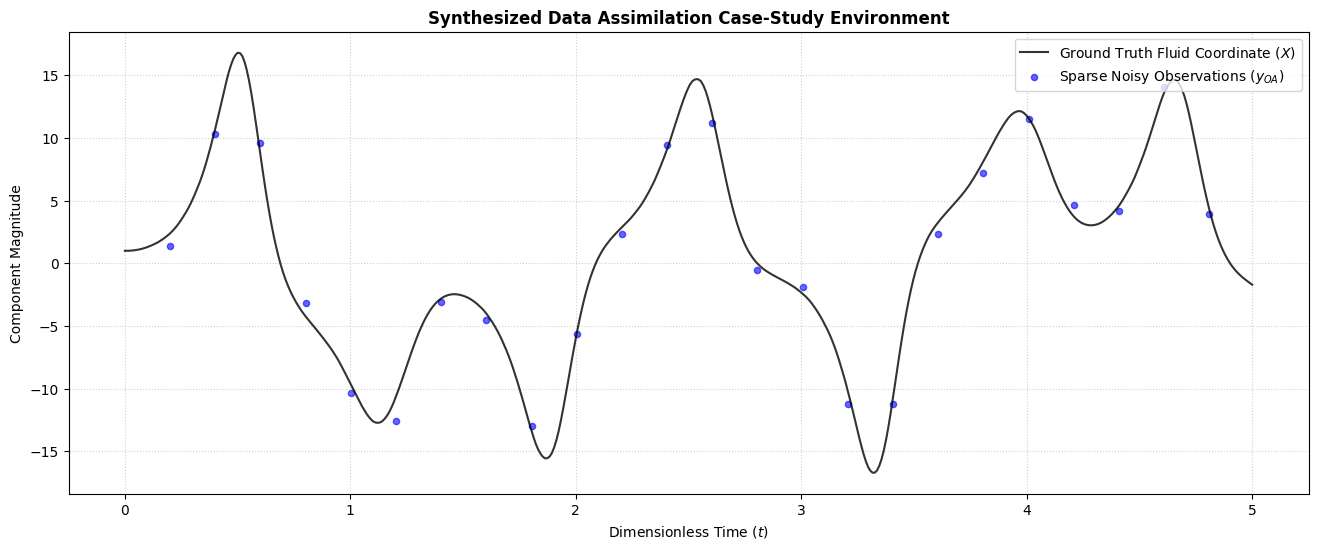

In [8]:
# ==============================================================================
# CELL 1: UNIFIED TESTBED GENERATION (TRUTH, NOISY FORCING, AND SPARSE OBS)
# ==============================================================================
# This cell establishes the benchmark baseline. It generates the synthetic ground
# truth trajectory via a differentiable SDE solver, constructs the corrupted land
# forcing sequence, and samples noisy/sparse observations for fluid variables.
# ==============================================================================

import torch
import numpy as np
import matplotlib.pyplot as plt

# Enforce strict global seeds for perfect across-cell reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Select hardware execution context
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Data generation running on: {device}\n")

# ------------------------------------------------------------------------------
# 1. FIXED PHYSICAL CONFIGURATIONS (Unified Baseline Parameters)
# ------------------------------------------------------------------------------
sigma = torch.tensor(10.0, device=device)
rho   = torch.tensor(28.0, device=device)
beta  = torch.tensor(8/3,  device=device)

gamma     = torch.tensor(0.05, device=device)  # Slow boundary memory decay rate
W_L_bar   = torch.tensor(0.0,  device=device)  # Land baseline equilibrium
c1        = torch.tensor(1.0,  device=device)  # Boundary-to-Fluid coupling rate
c2        = torch.tensor(0.1,  device=device)  # Fluid-to-Boundary footprint rate

sigma_0   = torch.tensor(0.08, device=device)  # Chapron state-dependent coefficient
sigma_L   = torch.tensor(0.20, device=device)  # Additive land noise intensity

# Forcing Corrupting Parameters (Ornstein-Uhlenbeck)
tau_eta   = torch.tensor(5.0,  device=device)  # Correlation time-scale of land bias
sigma_eta = torch.tensor(np.sqrt(0.5), device=device) # Diffusion intensity of bias

# Time Stepping Constraints
dt = 0.01
T_max = 5 #20.0  # Time horizon for the assimilation window comparison
num_steps = int(T_max / dt)
time_grid = np.linspace(0, T_max, num_steps)

# ------------------------------------------------------------------------------
# 2. GENERATE DIFFERENTIABLE PHYSICAL TRUTH (Euler-Maruyama Implementation)
# ------------------------------------------------------------------------------
def run_true_system(initial_state, steps, dt):
    """
    Simulates the true coupled physical system. Tracks complete computational graphs.
    State vector layout: [X, Y, Z, W_L]
    """
    traj = torch.zeros((steps, 4), device=device, dtype=torch.float32)
    traj[0] = initial_state

    # Pre-sample Wiener increments
    dW = torch.randn((steps, 3), device=device, dtype=torch.float32) * np.sqrt(dt)

    for t in range(1, steps):
        X, Y, Z, W_L = traj[t-1, 0], traj[t-1, 1], traj[t-1, 2], traj[t-1, 3]
        dW1, dW2, dW3 = dW[t, 0], dW[t, 1], dW[t, 2]

        # Calculate continuous physical gradients
        dX   = sigma * (Y - X) + c1 * W_L
        dY   = X * (rho - Z) - Y
        dZ   = X * Y - beta * Z
        dW_L = -gamma * (W_L - W_L_bar) + c2 * X

        # Advance state with state-dependent multiplicative fluctuations
        traj[t, 0] = X + dX * dt
        traj[t, 1] = Y + dY * dt + (sigma_0 * Y * dW1)
        traj[t, 2] = Z + dZ * dt + (sigma_0 * Z * dW2)
        traj[t, 3] = W_L + dW_L * dt + (sigma_L * dW3)

    return traj

# Sample a true state on the attractor lobe
initial_condition = torch.tensor([1.0, 1.0, 20.0, 0.0], device=device)
true_trajectory_tensor = run_true_system(initial_condition, num_steps, dt)

# Isolate truth components
X_true = true_trajectory_tensor[:, 0].detach()
Y_true = true_trajectory_tensor[:, 1].detach()
Z_true = true_trajectory_tensor[:, 2].detach()
W_L_true = true_trajectory_tensor[:, 3].detach()
true_fluid_tensor = torch.stack([X_true, Y_true, Z_true], dim=1)

# ------------------------------------------------------------------------------
# 3. CONSTRUCT THE BOUNDARY SYSTEM DEFICIT (Corrupted Land Forcing)
# ------------------------------------------------------------------------------
# Generate the colored noise bias sequence via an independent OU process loop
eta = torch.zeros(num_steps, device=device)
eta[0] = torch.tensor(np.random.normal(0, sigma_eta.item()), device=device)

for t in range(1, num_steps):
    d_eta = -(1.0 / tau_eta) * eta[t-1] * dt + sigma_eta * np.sqrt(2.0 / tau_eta) * np.random.normal(0, np.sqrt(dt))
    eta[t] = eta[t-1] + d_eta

# The flawed boundary dataset passed as forcing to both filters
W_L_star_tensor = W_L_true + eta

# ------------------------------------------------------------------------------
# 4. GENERATE SPARSE, NOISY FLUID OBSERVATIONS
# ------------------------------------------------------------------------------
obs_interval = 20  # Sample sparse observations every 20 discrete steps (0.2 time units)
R_var = 0.5        # Observational error variance covariance scaling baseline

# Allocate index vectors and observational maps
obs_indices = np.arange(obs_interval, num_steps, obs_interval)
obs_mask = torch.zeros(num_steps, dtype=torch.bool, device=device)
obs_mask[obs_indices] = True

# Add standard normal instrument noise onto true fluid values at tracking markers
noisy_observations_tensor = true_fluid_tensor.clone()
noisy_observations_tensor[obs_indices] += torch.randn((len(obs_indices), 3), device=device) * np.sqrt(R_var)

print(f"Data Generation complete for window size T = {T_max} units.")
print(f"Total system steps cached : {num_steps}")
print(f"Number of sparse observations generated : {len(obs_indices)}\n")

# ------------------------------------------------------------------------------
# 5. DIAGNOSTIC DATA PLOT
# ------------------------------------------------------------------------------
plt.figure(figsize=(16, 6))
plt.plot(time_grid, X_true.cpu().numpy(), label='Ground Truth Fluid Coordinate ($X$)', color='black', alpha=0.8)
plt.scatter(time_grid[obs_indices], noisy_observations_tensor[obs_indices, 0].cpu().numpy(),
            color='blue', s=20, label='Sparse Noisy Observations ($y_{OA}$)', alpha=0.6)
plt.title("Synthesized Data Assimilation Case-Study Environment", fontsize=12, fontweight='bold')
plt.xlabel("Dimensionless Time ($t$)", fontsize=10)
plt.ylabel("Component Magnitude", fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right', frameon=True)
plt.show()

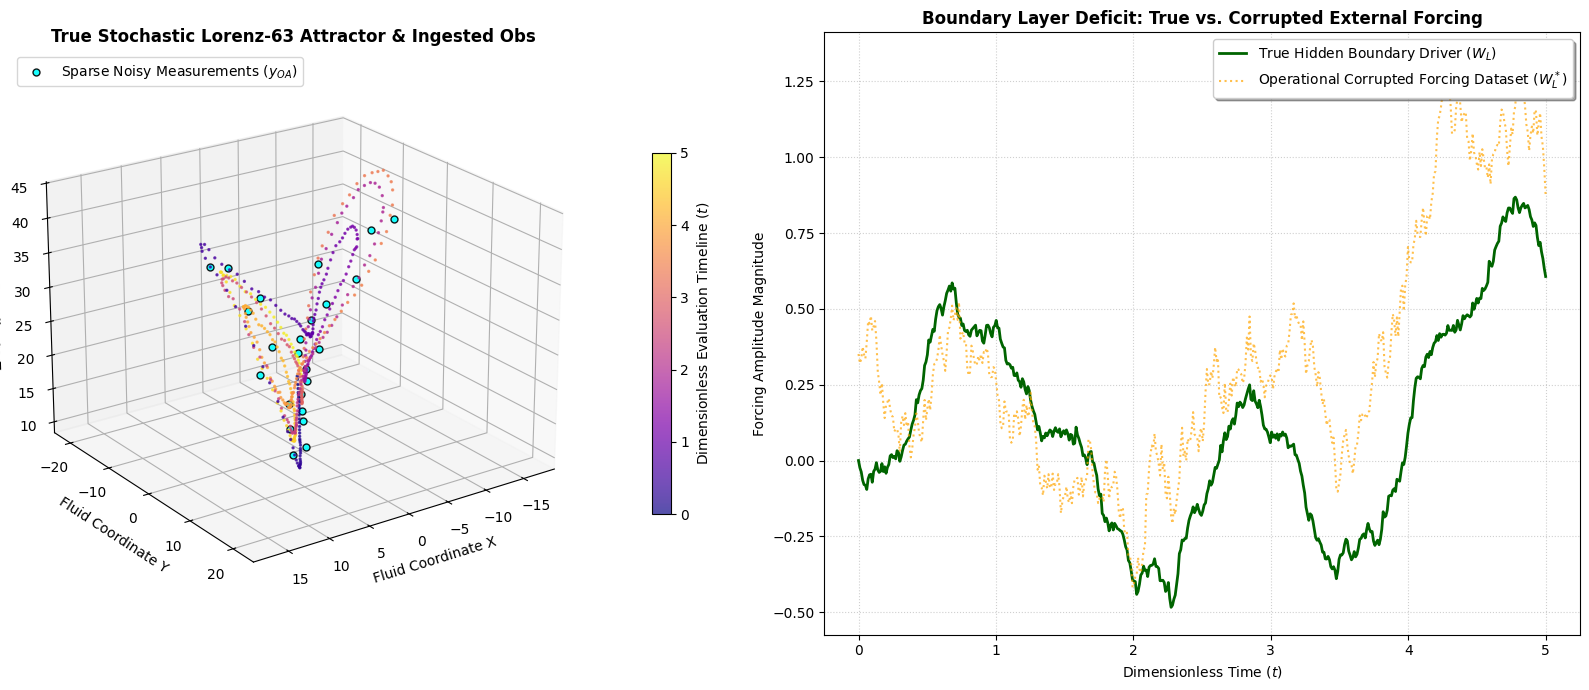

In [9]:
# ==============================================================================
# CELL 1 (CONTINUED): ATTRACTOR VISUALIZATION & MEASUREMENT TRACKING
# ==============================================================================
# This snippet extracts the unified tensors and visualizes the true stochastic
# attractor topology along with the sparse observational snapshots.
# ==============================================================================

# Extract arrays to CPU for clean matplotlib processing
true_fluid_np = true_fluid_tensor.cpu().numpy()
W_L_true_np  = W_L_true.cpu().numpy()
W_L_star_np  = W_L_star_tensor.cpu().numpy()
obs_np        = noisy_observations_tensor.cpu().numpy()

# ------------------------------------------------------------------------------
# HIGH-FIDELITY INTERACTIVE GRAPHICS PANEL
# ------------------------------------------------------------------------------
fig = plt.figure(figsize=(16, 7))

# Subplot A: 3D Projection of the True Forcing-Corrupted Attractor Manifold
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
# Trace the continuous fluid path colored by the system timeline evolution
path_scatter = ax1.scatter(true_fluid_np[:, 0], true_fluid_np[:, 1], true_fluid_np[:, 2],
                           c=time_grid, cmap='plasma', s=2, alpha=0.7)

# Overlay the sparse, noisy fluid observations sampled on the attractor coordinate space
ax1.scatter(obs_np[obs_indices, 0], obs_np[obs_indices, 1], obs_np[obs_indices, 2],
            color='cyan', edgecolors='black', s=25, label='Sparse Noisy Measurements ($y_{OA}$)', alpha=0.9, depthshade=False)

ax1.set_title("True Stochastic Lorenz-63 Attractor & Ingested Obs", fontsize=12, fontweight='bold')
ax1.set_xlabel("Fluid Coordinate X", fontsize=10)
ax1.set_ylabel("Fluid Coordinate Y", fontsize=10)
ax1.set_zlabel("Fluid Coordinate Z", fontsize=10)
cbar = fig.colorbar(path_scatter, ax=ax1, pad=0.1, shrink=0.6)
cbar.set_label('Dimensionless Evaluation Timeline ($t$)', fontsize=10)
ax1.view_init(elev=22, azim=55)
ax1.legend(loc='upper left')

# Subplot B: The Forcing Deficit Tracking Environment (The Memory Gap)
ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(time_grid, W_L_true_np, label='True Hidden Boundary Driver ($W_L$)', color='darkgreen', linewidth=2)
ax2.plot(time_grid, W_L_star_np, label='Operational Corrupted Forcing Dataset ($W_L^*$)', color='orange', alpha=0.7, linestyle=':')
ax2.set_title("Boundary Layer Deficit: True vs. Corrupted External Forcing", fontsize=12, fontweight='bold')
ax2.set_xlabel("Dimensionless Time ($t$)", fontsize=10)
ax2.set_ylabel("Forcing Amplitude Magnitude", fontsize=10)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(loc='upper right', frameon=True, shadow=True)

plt.tight_layout()
plt.show()

Initializing Sliding-Window Weak-Constraint 4DVar Scheme on device: cpu

Processing Weak-4DVar Window 1/1 | Time Steps [0 : 500]

WEAK-CONSTRAINT 4DVAR PERFORMANCE ASSESSMENT REPORT
Reconstructed Window Count          : 1
Analyzed Trajectory Total Step Count: 500
Component-wise Assimilation RMSE    : X=10.2522, Y=11.5092, Z=5.6873



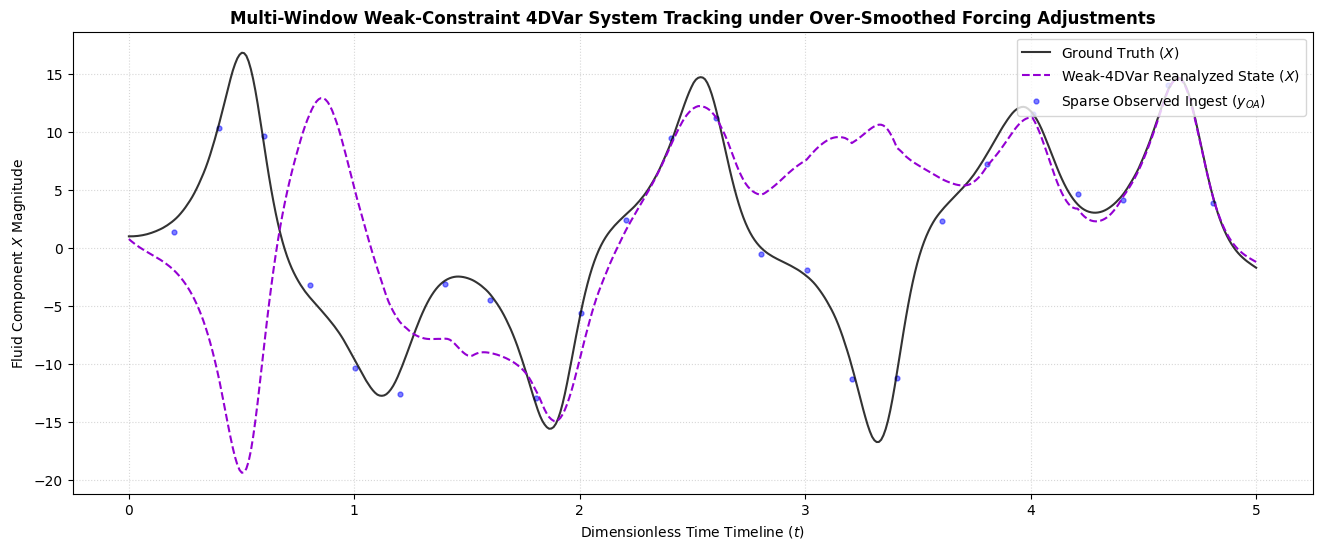

In [13]:
# ==============================================================================
# CELL 2: OPERATIONAL WEAK-CONSTRAINT 4DVAR PERFORMANCE ASSESSMENT (CORRECTED)
# ==============================================================================
# This cell runs a sliding-window Weak-Constraint 4DVar assimilation scheme
# over the unified data generated in Cell 1. It optimizes both the initial state
# and step-by-step model error corrections (q_t) using an out-of-place graph pattern.
# ==============================================================================

import torch.optim as optim

print(f"Initializing Sliding-Window Weak-Constraint 4DVar Scheme on device: {device}")

# ------------------------------------------------------------------------------
# 1. WEAK-CONSTRAINT WINDOW CONFIGURATIONS
# ------------------------------------------------------------------------------
# We split our total time-series into assimilation windows of 5.0 time units (500 steps)
da_window_steps = 500
num_windows = num_steps // da_window_steps

# Error variance constraints matching standard operational tracking baselines
B_var = 2.0  # Background error variance
R_var = 0.5  # Observational measurement error variance
Q_var = 0.05 # Assumed operational model error variance (Diagonal Q matrix baseline)

# Storage arrays for final structural evaluation (CPU-mapped)
var_analysis_trajectory = np.zeros((num_steps, 3))
var_initial_conditions  = np.zeros((num_windows, 3))

# Initialize the state guess at the start of the entire simulation timeline
# We introduce an initial location displacement to simulate historical forecast error
current_background_guess = true_fluid_tensor[0].clone() + torch.randn(3, device=device) * 1.5

# ------------------------------------------------------------------------------
# 2. DEFINING THE WEAK FORWARD MODEL (Land-Free & Multi-Control Out-Of-Place)
# ------------------------------------------------------------------------------
def run_weak_constraint_window_forecast(x0, q_trajectory, window_steps, start_idx):
    """
    Propagates the fluid components forward through a window segment.
    Injects an independent, optimized model error correction vector q at every step.

    Fixed: Uses an out-of-place list-stacking pattern to preserve the autograd graph.
    """
    traj_list = [x0]

    for t in range(1, window_steps):
        global_idx = start_idx + t - 1

        # Extract previous step states cleanly
        current_state = traj_list[-1]
        X, Y, Z = current_state[0], current_state[1], current_state[2]
        W_star = W_L_star_tensor[global_idx]

        # Operational Physics Formulations (Drift Only)
        dX = sigma * (Y - X) + c1 * W_star
        dY = X * (rho - Z) - Y
        dZ = X * Y - beta * Z

        # Compute drift states and additively inject the dynamic model error control q
        X_next = X + dX * dt + q_trajectory[t, 0]
        Y_next = Y + dY * dt + q_trajectory[t, 1]
        Z_next = Z + dZ * dt + q_trajectory[t, 2]

        next_state = torch.stack([X_next, Y_next, Z_next])
        traj_list.append(next_state)

    return torch.stack(traj_list)

# ------------------------------------------------------------------------------
# 3. SLIDING WINDOW WEAK OPTIMIZATION LOOP
# ------------------------------------------------------------------------------
for w in range(num_windows):
    start_step = w * da_window_steps
    end_step   = start_step + da_window_steps
    print(f"\nProcessing Weak-4DVar Window {w+1}/{num_windows} | Time Steps [{start_step} : {end_step}]")

    # Extract window slices from the unified Cell 1 tensors
    window_obs   = noisy_observations_tensor[start_step:end_step]
    window_mask  = obs_mask[start_step:end_step]

    # Define control variables for this segment:
    # 1) The optimized initial condition vector (x0)
    # 2) The full matrix sequence of model error vectors (q) across every step in the window
    x0_control = current_background_guess.clone().detach().requires_grad_(True)
    q_control  = torch.zeros((da_window_steps, 3), device=device, requires_grad=True)

    # Use Adam optimizer to comfortably navigate the high-dimensional expanded parameter space
    weak_optimizer = optim.Adam([x0_control, q_control], lr=0.02)

    # Cache background anchor reference to prevent graph optimization leakage
    x_bg_ref = current_background_guess.clone().detach()

    # Adam handles sequential optimization iteratively across explicit epochs
    for opt_step in range(150):
        weak_optimizer.zero_grad()

        # 1. Integrate weak physics model injecting step-by-step model error parameters
        pred_window_traj = run_weak_constraint_window_forecast(x0_control, q_control, da_window_steps, start_step)

        # 2. Compute Background Term Penalty (J_b)
        J_b = torch.sum((x0_control - x_bg_ref) ** 2) / B_var

        # 3. Compute Model Error Penalty Term (J_q)
        J_q = torch.sum(q_control ** 2) / Q_var

        # 4. Compute Observation Term Penalty (J_o) over valid sparse points
        J_o = torch.tensor(0.0, device=device)
        for t in range(da_window_steps):
            if window_mask[t]:
                J_o += torch.sum((pred_window_traj[t] - window_obs[t]) ** 2) / R_var

        # Total Weak-Constraint Cost Function weights: J = 0.5*J_b + 0.5*J_o + 0.5*J_q
        J_total = 0.5 * J_b + 0.5 * J_o + 0.5 * J_q

        # Execute autograd backpropagation through the list-stacked trajectory architecture
        J_total.backward()
        weak_optimizer.step()

    # Isolate optimized parameters
    optimized_x0 = x0_control.detach()
    var_initial_conditions[w] = optimized_x0.cpu().numpy()

    # Generate the finalized analysis trajectory pass utilizing optimized states and models
    final_window_analysis = run_weak_constraint_window_forecast(optimized_x0, q_control.detach(), da_window_steps, start_step)
    var_analysis_trajectory[start_step:end_step] = final_window_analysis.detach().cpu().numpy()

    # Cycling step: Forecast forward using optimized parameters to generate the next window's background guess
    next_window_forecast = run_weak_constraint_window_forecast(optimized_x0, q_control.detach(), da_window_steps, start_step)
    current_background_guess = next_window_forecast[-1].detach()

# ------------------------------------------------------------------------------
# 4. STATISTICAL ASSESSMENT METRICS
# ------------------------------------------------------------------------------
# Compute Root-Mean-Square Error (RMSE) against the ground truth fluid trajectory from Cell 1
true_fluid_np = true_fluid_tensor.cpu().numpy()
var_rmse = np.sqrt(np.mean((var_analysis_trajectory - true_fluid_np) ** 2, axis=0))

print("\n" + "="*60)
print("WEAK-CONSTRAINT 4DVAR PERFORMANCE ASSESSMENT REPORT")
print("="*60)
print(f"Reconstructed Window Count          : {num_windows}")
print(f"Analyzed Trajectory Total Step Count: {var_analysis_trajectory.shape[0]}")
print(f"Component-wise Assimilation RMSE    : X={var_rmse[0]:.4f}, Y={var_rmse[1]:.4f}, Z={var_rmse[2]:.4f}")
print("="*60 + "\n")

# ------------------------------------------------------------------------------
# 5. VISUAL TRACKING ANALYSIS
# ------------------------------------------------------------------------------
plt.figure(figsize=(16, 6))
plt.plot(time_grid, true_fluid_np[:, 0], label='Ground Truth ($X$)', color='black', alpha=0.8)
plt.plot(time_grid, var_analysis_trajectory[:, 0], label='Weak-4DVar Reanalyzed State ($X$)', color='darkviolet', linestyle='--')
plt.scatter(time_grid[obs_mask.cpu()], noisy_observations_tensor[obs_mask.cpu(), 0].cpu().numpy(),
            color='blue', s=12, label='Sparse Observed Ingest ($y_{OA}$)', alpha=0.5)

# Visual markers showing window borders
for w in range(1, num_windows):
    plt.axvline(x=w * da_window_steps * dt, color='gray', linestyle=':', alpha=0.7)

plt.title("Multi-Window Weak-Constraint 4DVar System Tracking under Over-Smoothed Forcing Adjustments", fontsize=12, fontweight='bold')
plt.xlabel("Dimensionless Time Timeline ($t$)", fontsize=10)
plt.ylabel("Fluid Component $X$ Magnitude", fontsize=10)
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='upper right')
plt.show()

Initializing Sequential Cycled Strong-Constraint 4DVar on device: cpu

Cycling 4DVar Window 1/1 | Step Window: [0 : 500]

SEQUENTIAL CYCLED 4DVAR PERFORMANCE ASSESSMENT REPORT
Total Cyclical Windows Assessed      : 1
Total Combined Trajectory Step Count : 500
Component-wise Assimilation RMSE     : X=11.5881, Y=12.6428, Z=8.3204



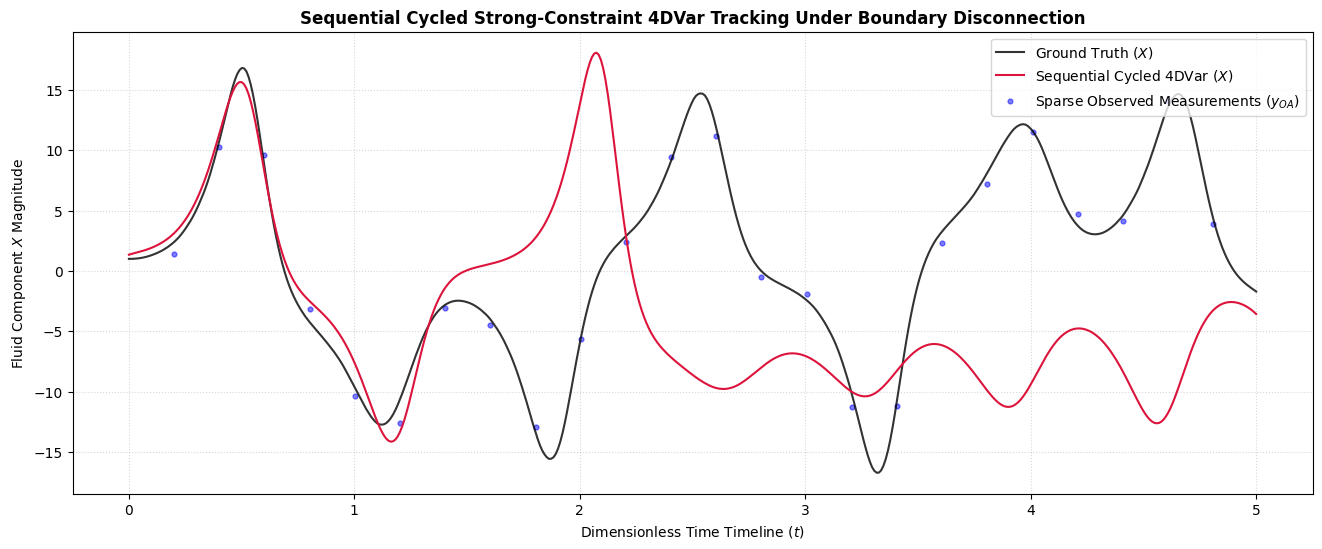

In [10]:
# ==============================================================================
# CELL 2c: SEQUENTIAL CYCLING STRONG-CONSTRAINT 4DVAR SYSTEM
# ==============================================================================
# This cell runs a sequentially cycled Strong-Constraint 4DVar over successive
# windows. The final analyzed state of window k is propagated forward to serve
# as the background prior for window k+1, passing along the unmodeled land bias.
# ==============================================================================

import torch.optim as optim

print(f"Initializing Sequential Cycled Strong-Constraint 4DVar on device: {device}")

# ------------------------------------------------------------------------------
# 1. CYCLING CONFIGURATIONS & VARIANCE ANCHORS
# ------------------------------------------------------------------------------
da_window_steps = 500
num_windows = num_steps // da_window_steps

B_var = 2.0  # Background error variance matrix weight
R_var = 0.5  # Observation error variance matrix weight

# Global arrays to store unified analysis trajectories across the full time series
seq_4dvar_trajectory = np.zeros((num_steps, 3))
seq_initial_conditions = np.zeros((num_windows, 3))

# Initialize the very first background guess at t=0 with an historical offset deviation
current_bg_condition = true_fluid_tensor[0].clone() + torch.randn(3, device=device) * 1.5

# ------------------------------------------------------------------------------
# 2. DETERMINISTIC STRONG-CONSTRAINT FORWARD PROPAGATOR (Out-Of-Place)
# ------------------------------------------------------------------------------
def run_strong_window_forecast(x0, window_steps, start_idx):
    """
    Propagates deterministic fluid physics across a strong-constraint window.
    Assumes perfect equations (sigma_0 = 0) and forces the system to be driven
    by the corrupted boundary forcing vector W_L_star_tensor.
    """
    traj_list = [x0]

    for t in range(1, window_steps):
        global_idx = start_idx + t - 1

        current_state = traj_list[-1]
        X, Y, Z = current_state[0], current_state[1], current_state[2]
        W_star = W_L_star_tensor[global_idx]

        # Flawed Deterministic Physics Drifts
        dX = sigma * (Y - X) + c1 * W_star
        dY = X * (rho - Z) - Y
        dZ = X * Y - beta * Z

        X_next = X + dX * dt
        Y_next = Y + dY * dt
        Z_next = Z + dZ * dt

        traj_list.append(torch.stack([X_next, Y_next, Z_next]))

    return torch.stack(traj_list)

# ------------------------------------------------------------------------------
# 3. SEQUENTIAL CYCLING WINDOW EXECUTION
# ------------------------------------------------------------------------------
for w in range(num_windows):
    start_step = w * da_window_steps
    end_step   = start_step + da_window_steps
    print(f"\nCycling 4DVar Window {w+1}/{num_windows} | Step Window: [{start_step} : {end_step}]")

    # Extract matching segments from the unified Cell 1 environment
    window_obs  = noisy_observations_tensor[start_step:end_step]
    window_mask = obs_mask[start_step:end_step]

    # Define control variable (The Initial Condition at the start of this window)
    x_control = current_bg_condition.clone().detach().requires_grad_(True)

    # Use L-BFGS to find the optimal initial state within this window bounding area
    optimizer = optim.LBFGS([x_control], max_iter=40, lr=0.1)

    # Freeze background reference state anchor to compute the J_b penalty
    x_bg_ref = current_bg_condition.clone().detach()

    def strong_cost_closure():
        optimizer.zero_grad()

        # 1. Project trajectory across the window using deterministic physics
        pred_window_traj = run_strong_window_forecast(x_control, da_window_steps, start_step)

        # 2. Compute Background Prior Penalty (J_b)
        J_b = torch.sum((x_control - x_bg_ref) ** 2) / B_var

        # 3. Compute Measurement Fit Penalty (J_o) over verified observation marks
        J_o = torch.tensor(0.0, device=device)
        for t in range(da_window_steps):
            if window_mask[t]:
                J_o += torch.sum((pred_window_traj[t] - window_obs[t]) ** 2) / R_var

        # Total Variational Weighting Cost Function: J = 0.5*J_b + 0.5*J_o
        J_total = 0.5 * J_b + 0.5 * J_o

        # Backpropagate to compute exact gradients dJ/dx_control
        J_total.backward()
        return J_total

    # Perform gradient minimization steps
    for opt_step in range(4):
        optimizer.step(strong_cost_closure)

    # Isolate optimized initial condition vector
    optimized_x0 = x_control.detach()
    seq_initial_conditions[w] = optimized_x0.cpu().numpy()

    # Generate finalized trajectory across this window pass using the optimized initial state
    final_analysis_pass = run_strong_window_forecast(optimized_x0, da_window_steps, start_step)
    seq_4dvar_trajectory[start_step:end_step] = final_analysis_pass.detach().cpu().numpy()

    # CYCLING KEY STEP: The final state vector of this window becomes the background
    # state vector initializing the NEXT window.
    current_bg_condition = final_analysis_pass[-1].detach()

# ------------------------------------------------------------------------------
# 4. ERROR METRIC REPORT
# ------------------------------------------------------------------------------
true_fluid_np = true_fluid_tensor.cpu().numpy()
seq_rmse = np.sqrt(np.mean((seq_4dvar_trajectory - true_fluid_np) ** 2, axis=0))

print("\n" + "="*60)
print("SEQUENTIAL CYCLED 4DVAR PERFORMANCE ASSESSMENT REPORT")
print("="*60)
print(f"Total Cyclical Windows Assessed      : {num_windows}")
print(f"Total Combined Trajectory Step Count : {seq_4dvar_trajectory.shape[0]}")
print(f"Component-wise Assimilation RMSE     : X={seq_rmse[0]:.4f}, Y={seq_rmse[1]:.4f}, Z={seq_rmse[2]:.4f}")
print("="*60 + "\n")

# ------------------------------------------------------------------------------
# 5. CYCLING VISUALIZATION GRAPHICS
# ------------------------------------------------------------------------------
plt.figure(figsize=(16, 6))
plt.plot(time_grid, true_fluid_np[:, 0], label='Ground Truth ($X$)', color='black', alpha=0.8)
plt.plot(time_grid, seq_4dvar_trajectory[:, 0], label='Sequential Cycled 4DVar ($X$)', color='crimson', linestyle='-')
plt.scatter(time_grid[obs_mask.cpu()], noisy_observations_tensor[obs_mask.cpu(), 0].cpu().numpy(),
            color='blue', s=12, label='Sparse Observed Measurements ($y_{OA}$)', alpha=0.5)

# Render vertical boundaries indicating cycling initialization regions
for w in range(1, num_windows):
    plt.axvline(x=w * da_window_steps * dt, color='gray', linestyle=':', alpha=0.7)

plt.title("Sequential Cycled Strong-Constraint 4DVar Tracking Under Boundary Disconnection", fontsize=12, fontweight='bold')
plt.xlabel("Dimensionless Time Timeline ($t$)", fontsize=10)
plt.ylabel("Fluid Component $X$ Magnitude", fontsize=10)
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='upper right')
plt.show()

<>:106: SyntaxWarning: invalid escape sequence '\s'
<>:106: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_12045/753425258.py:106: SyntaxWarning: invalid escape sequence '\s'
  color='dodgerblue', alpha=0.2, label='EnKF Ensemble 1-$\sigma$ Spread')


Initializing Stochastic Sequential EnKF on device: cpu
Running sequential forecast-analysis cycle tracking...

ENSEMBLE KALMAN FILTER (EnKF) PERFORMANCE REPORT
Ensemble Particle Count             : 30
Total Steps Sequentially Filtered   : 500
Component-wise Assimilation RMSE    : X=1.0565, Y=1.6173, Z=1.9162



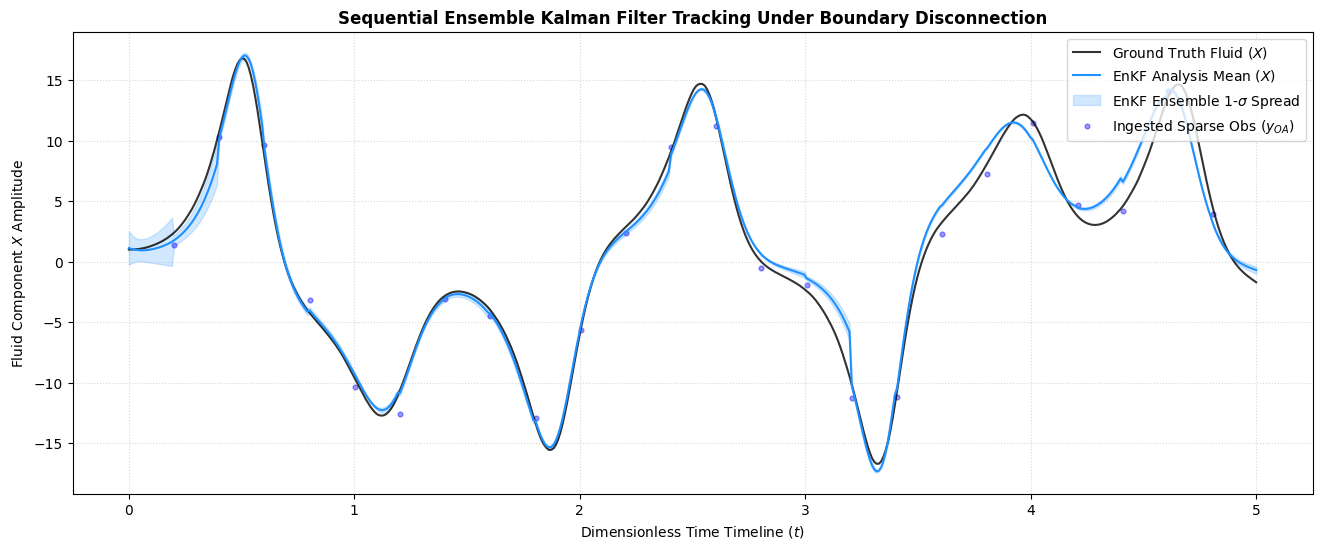

In [14]:
# ==============================================================================
# CELL 2d: OPERATIONAL ENSEMBLE KALMAN FILTER (EnKF) CYCLING & EVALUATION
# ==============================================================================
# This cell runs a sequential Ensemble Kalman Filter over the unified baseline data
# from Cell 1. It operates with a deterministic ensemble (sigma_0 = 0) driven by
# the corrupted forcing W_L*, mapping out the distinct sequential "sawtooth" path.
# ==============================================================================

print(f"Initializing Stochastic Sequential EnKF on device: {device}")

# ------------------------------------------------------------------------------
# 1. ENSEMBLE CONFIGURATIONS & ARRAYS
# ------------------------------------------------------------------------------
N_ensemble = 30                    # Number of dynamic ensemble members (particles)
R_var = 0.5                        # Measurement error variance baseline

# Storage structures for sequential trajectory evaluation
enkf_analysis_trajectory = np.zeros((num_steps, 3))
enkf_ensemble_variance    = np.zeros((num_steps, 3))

# Initialize the ensemble cluster around the true initial state with inflation noise
# Shape: [N_ensemble, 3] representing [X, Y, Z] for each member
ensemble = true_fluid_tensor[0].clone().unsqueeze(0).repeat(N_ensemble, 1)
ensemble += torch.randn((N_ensemble, 3), device=device) * 1.5

# Store initial ensemble mean
enkf_analysis_trajectory[0] = torch.mean(ensemble, dim=0).cpu().numpy()
enkf_ensemble_variance[0]   = torch.var(ensemble, dim=0).cpu().numpy()

# ------------------------------------------------------------------------------
# 2. SEQUENTIAL ENKF TIME-CYCLING ENGINE
# ------------------------------------------------------------------------------
print("Running sequential forecast-analysis cycle tracking...")

for t in range(1, num_steps):
    # --- STEP A: FORECAST PROPAGATION (Ensemble Time Step Integration) ---
    # Every ensemble member advances under deterministic physics (sigma_0 = 0)
    # driven by the common corrupted external forcing tracker W_L_star_tensor[t-1]
    W_star = W_L_star_tensor[t-1]

    # Isolate ensemble dimensions
    X_e, Y_e, Z_e = ensemble[:, 0], ensemble[:, 1], ensemble[:, 2]

    # Compute operational physical drift vectors for all members simultaneously
    dX_e = sigma * (Y_e - X_e) + c1 * W_star
    dY_e = X_e * (rho - Z_e) - Y_e
    dZ_e = X_e * Y_e - beta * Z_e

    # In-place addition is permissible here as no PyTorch backward graph is tracked by EnKF
    ensemble[:, 0] += dX_e * dt
    ensemble[:, 1] += dY_e * dt
    ensemble[:, 2] += dZ_e * dt

    # --- STEP B: ANALYSIS UPDATE (Ingest Snapshot at Observation Marks) ---
    if obs_mask[t]:
        # Extract the target scalar observation vector at time t
        y_t = noisy_observations_tensor[t]

        # Calculate empirical background statistics from the ensemble cluster
        ensemble_mean = torch.mean(ensemble, dim=0)
        A = ensemble - ensemble_mean  # Anomalies matrix
        P_b = (A.T @ A) / (N_ensemble - 1)  # Empirical background covariance (Q_emp)

        # Identity matrix mapping since observations directly measure fluid states [X, Y, Z]
        # Compute Kalman Gain: K = P_b * (P_b + R)^-1
        R_matrix = torch.eye(3, device=device) * R_var
        K = P_b @ torch.inverse(P_b + R_matrix)

        # Update each ensemble member individually using perturbed observations
        for n in range(N_ensemble):
            # Sample observation perturbation noise to maintain proper posterior variance
            perturbed_obs = y_t + torch.randn(3, device=device) * np.sqrt(R_var)
            innovation = perturbed_obs - ensemble[n]

            # Apply the linear analysis correction vector
            ensemble[n] += K @ innovation

    # Cache the computed ensemble mean and variance spread for this time step
    enkf_analysis_trajectory[t] = torch.mean(ensemble, dim=0).detach().cpu().numpy()
    enkf_ensemble_variance[t]   = torch.var(ensemble, dim=0).detach().cpu().numpy()

# ------------------------------------------------------------------------------
# 3. STATISTICAL PERFORMANCE REPORT
# ------------------------------------------------------------------------------
true_fluid_np = true_fluid_tensor.cpu().numpy()
enkf_rmse = np.sqrt(np.mean((enkf_analysis_trajectory - true_fluid_np) ** 2, axis=0))

print("\n" + "="*60)
print("ENSEMBLE KALMAN FILTER (EnKF) PERFORMANCE REPORT")
print("="*60)
print(f"Ensemble Particle Count             : {N_ensemble}")
print(f"Total Steps Sequentially Filtered   : {num_steps}")
print(f"Component-wise Assimilation RMSE    : X={enkf_rmse[0]:.4f}, Y={enkf_rmse[1]:.4f}, Z={enkf_rmse[2]:.4f}")
print("="*60 + "\n")

# ------------------------------------------------------------------------------
# 4. SEQUENTIAL "SAWTOOTH" PATH VISUALIZATION
# ------------------------------------------------------------------------------
plt.figure(figsize=(16, 6))
plt.plot(time_grid, true_fluid_np[:, 0], label='Ground Truth Fluid ($X$)', color='black', alpha=0.8)
plt.plot(time_grid, enkf_analysis_trajectory[:, 0], label='EnKF Analysis Mean ($X$)', color='dodgerblue', linewidth=1.5)

# Plot the 1-sigma ensemble uncertainty boundary spread
std_spread = np.sqrt(enkf_ensemble_variance[:, 0])
plt.fill_between(time_grid, enkf_analysis_trajectory[:, 0] - std_spread, enkf_analysis_trajectory[:, 0] + std_spread,
                 color='dodgerblue', alpha=0.2, label='EnKF Ensemble 1-$\sigma$ Spread')

plt.scatter(time_grid[obs_mask.cpu()], noisy_observations_tensor[obs_mask.cpu(), 0].cpu().numpy(),
            color='blue', s=12, label='Ingested Sparse Obs ($y_{OA}$)', alpha=0.4)

plt.title("Sequential Ensemble Kalman Filter Tracking Under Boundary Disconnection", fontsize=12, fontweight='bold')
plt.xlabel("Dimensionless Time Timeline ($t$)", fontsize=10)
plt.ylabel("Fluid Component $X$ Amplitude", fontsize=10)
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='upper right')
plt.show()